In [1]:
import torch
import requests

print("="*80)
print(f"{'PHASE 1: THE FUEL (DATA & TOKENIZATION)':^80}")
print("="*80)

# 1. DOWNLOAD THE DATA
print("[Step 1] Downloading 'Tiny Shakespeare'...")
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
text = requests.get(url).text
print(f"✅ Success! Downloaded {len(text):,} characters of Shakespeare.")

# 2. BUILD THE VOCABULARY
# Find every unique character used in the text (letters, punctuation, newlines)
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"\n[Step 2] Building Vocabulary...")
print(f"Total unique characters found (Vocab Size): {vocab_size}")
print(f"The Dictionary: '{''.join(chars)}'")

# 3. CREATE THE TRANSLATOR (ENCODER/DECODER)
# Create a mapping from character to integer (e.g., 'a' -> 39) and vice versa
stoi = {ch: i for i, ch in enumerate(chars)} # String to Integer
itos = {i: ch for i, ch in enumerate(chars)} # Integer to String

# The actual translation functions
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# 4. TEST THE TRANSLATOR
print("\n[Step 3] Testing the Tokenizer...")
sample_text = "To be, or not to be"
encoded_math = encode(sample_text)
decoded_text = decode(encoded_math)

print(f"Original Text:  '{sample_text}'")
print(f"Encoded Tensors: {encoded_math}")
print(f"Decoded Back:   '{decoded_text}'")

# 5. CONVERT ENTIRE DATASET TO PYTORCH TENSOR
data = torch.tensor(encode(text), dtype=torch.long)
print(f"\n[Step 4] Final Dataset Ready!")
print(f"Shape of entire Shakespeare tensor: {list(data.shape)}")
print(f"First 20 tokens look like: {data[:20].tolist()}")
print("="*80)

                    PHASE 1: THE FUEL (DATA & TOKENIZATION)                     
[Step 1] Downloading 'Tiny Shakespeare'...
✅ Success! Downloaded 1,115,394 characters of Shakespeare.

[Step 2] Building Vocabulary...
Total unique characters found (Vocab Size): 65
The Dictionary: '
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'

[Step 3] Testing the Tokenizer...
Original Text:  'To be, or not to be'
Encoded Tensors: [32, 53, 1, 40, 43, 6, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43]
Decoded Back:   'To be, or not to be'

[Step 4] Final Dataset Ready!
Shape of entire Shakespeare tensor: [1115394]
First 20 tokens look like: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]


In [2]:
stoi

{'\n': 0,
 ' ': 1,
 '!': 2,
 '$': 3,
 '&': 4,
 "'": 5,
 ',': 6,
 '-': 7,
 '.': 8,
 '3': 9,
 ':': 10,
 ';': 11,
 '?': 12,
 'A': 13,
 'B': 14,
 'C': 15,
 'D': 16,
 'E': 17,
 'F': 18,
 'G': 19,
 'H': 20,
 'I': 21,
 'J': 22,
 'K': 23,
 'L': 24,
 'M': 25,
 'N': 26,
 'O': 27,
 'P': 28,
 'Q': 29,
 'R': 30,
 'S': 31,
 'T': 32,
 'U': 33,
 'V': 34,
 'W': 35,
 'X': 36,
 'Y': 37,
 'Z': 38,
 'a': 39,
 'b': 40,
 'c': 41,
 'd': 42,
 'e': 43,
 'f': 44,
 'g': 45,
 'h': 46,
 'i': 47,
 'j': 48,
 'k': 49,
 'l': 50,
 'm': 51,
 'n': 52,
 'o': 53,
 'p': 54,
 'q': 55,
 'r': 56,
 's': 57,
 't': 58,
 'u': 59,
 'v': 60,
 'w': 61,
 'x': 62,
 'y': 63,
 'z': 64}

In [3]:
itos

{0: '\n',
 1: ' ',
 2: '!',
 3: '$',
 4: '&',
 5: "'",
 6: ',',
 7: '-',
 8: '.',
 9: '3',
 10: ':',
 11: ';',
 12: '?',
 13: 'A',
 14: 'B',
 15: 'C',
 16: 'D',
 17: 'E',
 18: 'F',
 19: 'G',
 20: 'H',
 21: 'I',
 22: 'J',
 23: 'K',
 24: 'L',
 25: 'M',
 26: 'N',
 27: 'O',
 28: 'P',
 29: 'Q',
 30: 'R',
 31: 'S',
 32: 'T',
 33: 'U',
 34: 'V',
 35: 'W',
 36: 'X',
 37: 'Y',
 38: 'Z',
 39: 'a',
 40: 'b',
 41: 'c',
 42: 'd',
 43: 'e',
 44: 'f',
 45: 'g',
 46: 'h',
 47: 'i',
 48: 'j',
 49: 'k',
 50: 'l',
 51: 'm',
 52: 'n',
 53: 'o',
 54: 'p',
 55: 'q',
 56: 'r',
 57: 's',
 58: 't',
 59: 'u',
 60: 'v',
 61: 'w',
 62: 'x',
 63: 'y',
 64: 'z'}

In [4]:
import torch

# --- 1. DEVICE SETUP FOR RTX 3050 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Make sure you see your RTX 3050 listed above!\n")

# --- 2. HYPERPARAMETERS (Tuned for RTX 3050 4GB/8GB) ---
batch_size = 32 # How many independent sequences to process in parallel
block_size = 64 # Maximum context length for predictions

# --- 3. TRAIN / VAL SPLIT ---
# We keep 10% of the data hidden from the model to test if it's actually learning
# or just blindly memorizing the text.
n = int(0.9 * len(data)) 
train_data = data[:n]
val_data = data[n:]

# --- 4. THE DATA LOADER ---
def get_batch(split):
    # Select the right dataset
    d = train_data if split == 'train' else val_data
    
    # Generate 32 random starting indices for our batch
    ix = torch.randint(len(d) - block_size, (batch_size,))
    
    # Stack the chunks into tensors (X is input, Y is the target shifted by 1)
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    
    # Shoot the data straight into your RTX 3050's VRAM!
    x, y = x.to(device), y.to(device)
    return x, y

# --- 5. TEST THE LOADER ---
xb, yb = get_batch('train')
print("[Data Loader Test]")
print(f"Inputs (X) shape:  {list(xb.shape)} -> (batch_size, block_size)")
print(f"Targets (Y) shape: {list(yb.shape)} -> (batch_size, block_size)")

print("\n--- Visualizing the Offset ---")
print("Notice how the Target (Y) is just the Context (X) shifted by 1 character:")
print(f"Context (X): '{decode(xb[0].tolist())}'")
print(f"Target  (Y): '{decode(yb[0].tolist())}'")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
Make sure you see your RTX 3050 listed above!

[Data Loader Test]
Inputs (X) shape:  [32, 64] -> (batch_size, block_size)
Targets (Y) shape: [32, 64] -> (batch_size, block_size)

--- Visualizing the Offset ---
Notice how the Target (Y) is just the Context (X) shifted by 1 character:
Context (X): 'envy. Fix thy foot.

MARCIUS:
Let the first budger die the other'
Target  (Y): 'nvy. Fix thy foot.

MARCIUS:
Let the first budger die the other''


In [5]:
import torch.nn as nn
from torch.nn import functional as F

# --- HYPERPARAMETERS FOR OUR NANO-MODEL ---
n_embd = 256      # The size of our token embedding (d_model)
n_head = 4        # Number of Attention heads
n_layer = 4       # How many Transformer blocks we will stack
dropout = 0.1     # Prevents overfitting by randomly turning off 10% of neurons

# --- 1. THE ATTENTION ROUTER ---
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False) # Q, K, V all at once!
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)     # Output blender
        self.dropout = nn.Dropout(dropout)
        
        # The Mask: Prevents words from looking into the future
        self.register_buffer("bias", torch.tril(torch.ones(block_size, block_size))
                                     .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()
        
        # Calculate Q, K, V
        qkv = self.c_attn(x)
        q, k, v = qkv.split(n_embd, dim=2)
        
        # Slice into heads: (B, T, C) -> (B, T, Heads, Head_Dim) -> (B, Heads, T, Head_Dim)
        k = k.view(B, T, n_head, C // n_head).transpose(1, 2)
        q = q.view(B, T, n_head, C // n_head).transpose(1, 2)
        v = v.view(B, T, n_head, C // n_head).transpose(1, 2)
        
        # Attention Math: (Q * K^T) / sqrt(d_k)
        att = (q @ k.transpose(-2, -1)) * (1.0 / (k.size(-1) ** 0.5))
        
        # Apply the Mask (So "To" can't see "be")
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        
        # Multiply by V
        y = att @ v
        
        # Reassemble the heads
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

# --- 2. THE SWIGLU BRAIN ---
class SwiGLU(nn.Module):
    def __init__(self):
        super().__init__()
        # The 8/3 Dimension Hack we learned!
        hidden_dim = int(4 * n_embd * (2/3))
        # Round up to a multiple of 64 for our tiny GPU model
        self.hidden_dim = 64 * ((hidden_dim + 64 - 1) // 64) 
        
        self.w_gate = nn.Linear(n_embd, self.hidden_dim, bias=False)
        self.w_up   = nn.Linear(n_embd, self.hidden_dim, bias=False)
        self.w_down = nn.Linear(self.hidden_dim, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # The exact math from Lesson 3.5: Gate * Knowledge
        gate = F.silu(self.w_gate(x))
        knowledge = self.w_up(x)
        return self.dropout(self.w_down(gate * knowledge))

# --- 3. THE LAYER ASSEMBLY ---
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention()
        self.ln_2 = nn.LayerNorm(n_embd)
        self.ffn = SwiGLU()

    def forward(self, x):
        # x = x + Attention(Norm(x))
        x = x + self.attn(self.ln_1(x))
        # x = x + FFN(Norm(x))
        x = x + self.ffn(self.ln_2(x))
        return x

# --- 4. THE MASTER MODEL ---
class MicroBard(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Look up the meaning of the character
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        # 2. Look up the physical position of the character in the sentence
        self.position_embedding = nn.Embedding(block_size, n_embd)
        
        # 3. Stack our Transformer Blocks
        self.blocks = nn.Sequential(*[TransformerBlock() for _ in range(n_layer)])
        
        # 4. The Final Output Blender
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        
        # Get Embeddings and Add them together
        tok_emb = self.token_embedding(idx) # (B, T, C)
        pos_emb = self.position_embedding(torch.arange(T, device=device)) # (T, C)
        x = tok_emb + pos_emb # The model now knows WHAT the word is, and WHERE it is.
        
        # Pass through the stacked layers
        x = self.blocks(x)
        x = self.ln_f(x)
        
        # Final prediction logits
        logits = self.lm_head(x) # (B, T, vocab_size)
        
        # Calculate Loss (How stupid is the model currently?)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_reshaped = logits.view(B*T, C)
            targets_reshaped = targets.view(B*T)
            loss = F.cross_entropy(logits_reshaped, targets_reshaped)
            
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        # A helper function to make the model actually "talk"
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:] # Crop context
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] # Focus on the last time step
            probs = F.softmax(logits, dim=-1) # Turn to percentages
            idx_next = torch.multinomial(probs, num_samples=1) # Roll the dice
            idx = torch.cat((idx, idx_next), dim=1) # Append and repeat
        self.train()
        return idx

# Load the model directly into your RTX 3050!
model = MicroBard()
model = model.to(device)
print(f"✅ MicroBard assembled! Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} Million")

✅ MicroBard assembled! Total parameters: 3.27 Million


In [6]:
import torch

print("="*80)
print(f"{'PHASE 4 & 5: TRAINING THE AI':^80}")
print("="*80)

# --- 1. THE BEFORE SNAPSHOT ---
print("Let's see what the untrained AI sounds like (Absolute Gibberish):")
context = torch.zeros((1, 1), dtype=torch.long, device=device) # Start with a blank token
untrained_output = decode(model.generate(context, max_new_tokens=100)[0].tolist())
print(f"Untrained Output:\n{untrained_output}\n")
print("-" * 80)

# --- 2. THE OPTIMIZER ---
# AdamW is the industry standard. Learning rate tells it how big of a step to take.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
max_iters = 3000      # How many batches to train on
eval_interval = 500   # How often to check our test score

# Helper function to check test score without messing up gradients
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(200) # Check 200 batches to get a good average
        for k in range(200):
            X, Y = get_batch(split)
            logits, loss = model(X, targets=Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# --- 3. THE TRAINING LOOP (THE MATRIX AWAKENS) ---
print("🔥 Firing up the RTX 3050... Training Started!")
import time
start_time = time.time()

for iter in range(max_iters):
    # Every once in a while, evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"Step {iter:4d}: Train Loss {losses['train']:.4f}, Val Loss {losses['val']:.4f}")

    # 1. Sample a batch of data
    xb, yb = get_batch('train')

    # 2. Evaluate the loss
    logits, loss = model(xb, targets=yb)
    
    # 3. Backpropagation! 
    # Clear the old gradients, calculate the new ones, and update the weights.
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

end_time = time.time()
print(f"\n✅ Training Complete in {(end_time - start_time):.2f} seconds!")
print("="*80)

# --- 4. THE AFTER SNAPSHOT ---
print("\nLet's hear from the trained AI:")
context = torch.zeros((1, 1), dtype=torch.long, device=device)
trained_output = decode(model.generate(context, max_new_tokens=300)[0].tolist())
print(f"Trained Output:\n{trained_output}")
print("="*80)

                          PHASE 4 & 5: TRAINING THE AI                          
Let's see what the untrained AI sounds like (Absolute Gibberish):
Untrained Output:

I!rSJIoDYZyyLPMZoxrcqn3zTh;qE3oZWRKk-bCVK,n,Mn BgKg'LhVyavInMlVc&ZJnGnVms$df QFu,UUiiyEf-lp?vfUbdymt

--------------------------------------------------------------------------------
🔥 Firing up the RTX 3050... Training Started!
Step    0: Train Loss 4.3623, Val Loss 4.3535
Step  500: Train Loss 1.6527, Val Loss 1.8097
Step 1000: Train Loss 1.4877, Val Loss 1.6802
Step 1500: Train Loss 1.4138, Val Loss 1.6214
Step 2000: Train Loss 1.3792, Val Loss 1.5964
Step 2500: Train Loss 1.3506, Val Loss 1.5727
Step 2999: Train Loss 1.3172, Val Loss 1.5659

✅ Training Complete in 110.56 seconds!

Let's hear from the trained AI:
Trained Output:

Some you and be to speak: the house of York,
As many gave gainsating good as histop themself,
Which fourth though fair of shreel
They in the free ufflue for a thanks thou as fore
so the strict,

# ADAM vs MUON optimizer

                    THE GRAND SHOWDOWN: ADAMW VS HYBRID MUON                    
🚀 Launching Training Loop (2000 Iterations)...
Step    0 | Adam Loss: 4.3560 | Muon Loss: 4.3539
Step  200 | Adam Loss: 2.3034 | Muon Loss: 2.2327
Step  400 | Adam Loss: 1.9968 | Muon Loss: 1.9123
Step  600 | Adam Loss: 1.7964 | Muon Loss: 1.7600
Step  800 | Adam Loss: 1.6708 | Muon Loss: 1.6598
Step 1000 | Adam Loss: 1.7228 | Muon Loss: 1.7337
Step 1200 | Adam Loss: 1.6147 | Muon Loss: 1.6447
Step 1400 | Adam Loss: 1.5705 | Muon Loss: 1.5740
Step 1600 | Adam Loss: 1.5066 | Muon Loss: 1.5267
Step 1800 | Adam Loss: 1.4945 | Muon Loss: 1.5202
✅ Training Complete in 191.94 seconds.


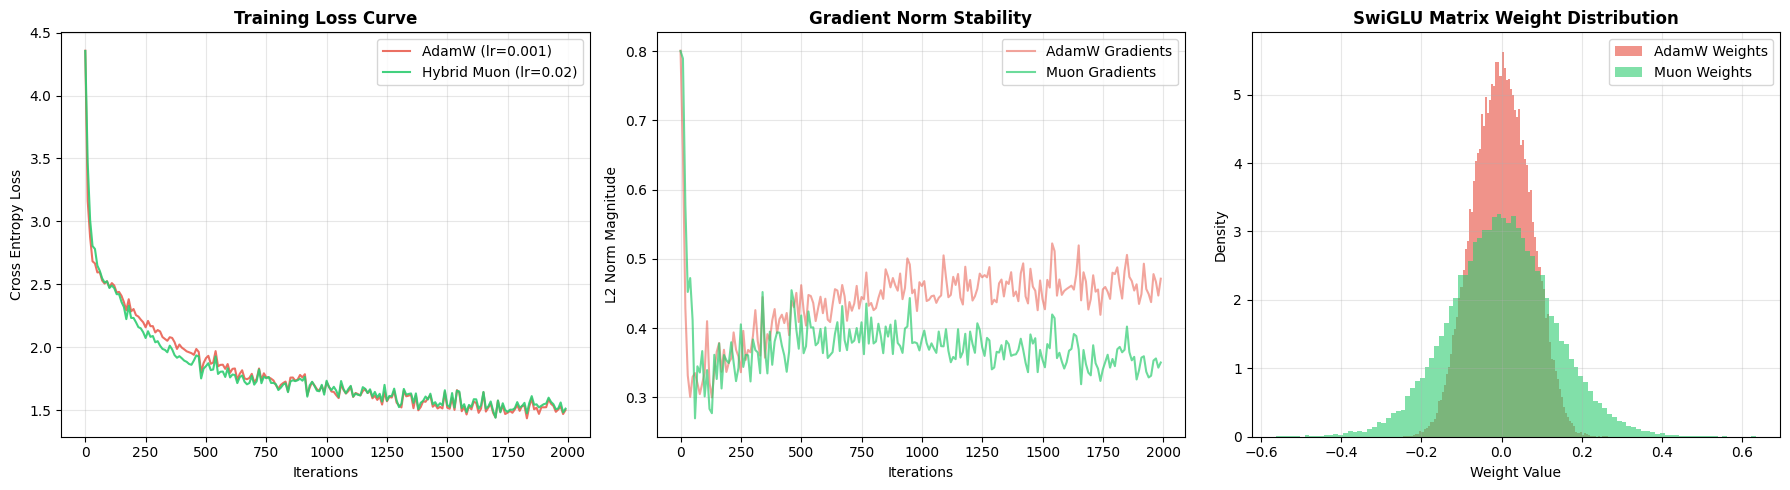

In [7]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import time

print("="*80)
print(f"{'THE GRAND SHOWDOWN: ADAMW VS HYBRID MUON':^80}")
print("="*80)

# --- 1. HYPERPARAMETERS & SETUP ---
# Assuming 'device', 'train_data', 'val_data', 'vocab_size', and 'get_batch' are still in memory!
block_size = 64
n_embd = 128   # Scaled down slightly so both models fit easily in your RTX 3050 VRAM simultaneously
n_head = 4
n_layer = 4
dropout = 0.1
max_iters = 2000
eval_interval = 200

# --- 2. THE ARCHITECTURE (From Phase 3) ---
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("bias", torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(n_embd, dim=2)
        k = k.view(B, T, n_head, C // n_head).transpose(1, 2)
        q = q.view(B, T, n_head, C // n_head).transpose(1, 2)
        v = v.view(B, T, n_head, C // n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / (k.size(-1) ** 0.5))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class SwiGLU(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_dim = int(4 * n_embd * (2/3))
        self.hidden_dim = 64 * ((hidden_dim + 64 - 1) // 64) 
        self.w_gate = nn.Linear(n_embd, self.hidden_dim, bias=False)
        self.w_up   = nn.Linear(n_embd, self.hidden_dim, bias=False)
        self.w_down = nn.Linear(self.hidden_dim, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.w_down(F.silu(self.w_gate(x)) * self.w_up(x)))

class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention()
        self.ln_2 = nn.LayerNorm(n_embd)
        self.ffn = SwiGLU()
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffn(self.ln_2(x))
        return x

class MicroBard(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[TransformerBlock() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

# --- 3. CLONING THE MODELS FOR A FAIR RACE ---
torch.manual_seed(1337)
model_adam = MicroBard().to(device)
model_muon = MicroBard().to(device)
model_muon.load_state_dict(model_adam.state_dict()) # Exact same starting brain

# --- 4. OPTIMIZER SETUP ---
# Baseline: AdamW
opt_adam = torch.optim.AdamW(model_adam.parameters(), lr=1e-3)

# Challenger: Muon (The Custom Class)
class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95):
        super().__init__(params, dict(lr=lr, momentum=momentum))
    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                G = p.grad
                state = self.state[p]
                if 'buf' not in state: state['buf'] = torch.zeros_like(G)
                buf = state['buf']
                buf.mul_(group['momentum']).add_(G, alpha=1 - group['momentum'])
                X_opt = buf
                m, n = X_opt.shape
                transposed = m > n
                if transposed: X_opt = X_opt.T
                X_opt = X_opt / (torch.linalg.matrix_norm(X_opt) + 1e-8)
                for _ in range(5):
                    A = X_opt @ X_opt.T
                    X_opt = 1.5 * X_opt - 0.5 * (A @ X_opt)
                if transposed: X_opt = X_opt.T
                p.add_(X_opt, alpha=-group['lr'])

# The Hybrid Router for Muon
muon_params = []
adamw_params = []
for name, p in model_muon.named_parameters():
    if not p.requires_grad: continue
    if len(p.shape) == 2 and 'embedding' not in name and 'lm_head' not in name:
        muon_params.append(p)
    else:
        adamw_params.append(p)

opt_muon_2d = Muon(muon_params, lr=0.02)
opt_muon_1d = torch.optim.AdamW(adamw_params, lr=1e-3)

# --- 5. THE DATA RECORDERS ---
history = {
    'iters': [],
    'adam_loss': [], 'muon_loss': [],
    'adam_grad_norm': [], 'muon_grad_norm': []
}

def get_grad_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

# --- 6. THE TRAINING LOOP ---
print("🚀 Launching Training Loop (2000 Iterations)...")
start_time = time.time()

for iter in range(max_iters):
    xb, yb = get_batch('train')
    
    # --- ADAMW TURN ---
    logits_a, loss_a = model_adam(xb, targets=yb)
    opt_adam.zero_grad(set_to_none=True)
    loss_a.backward()
    grad_norm_a = get_grad_norm(model_adam)
    opt_adam.step()
    
    # --- MUON TURN ---
    logits_m, loss_m = model_muon(xb, targets=yb)
    opt_muon_2d.zero_grad(set_to_none=True)
    opt_muon_1d.zero_grad(set_to_none=True)
    loss_m.backward()
    grad_norm_m = get_grad_norm(model_muon)
    opt_muon_2d.step()
    opt_muon_1d.step()
    
    # --- RECORDING ---
    if iter % 10 == 0:
        history['iters'].append(iter)
        history['adam_loss'].append(loss_a.item())
        history['muon_loss'].append(loss_m.item())
        history['adam_grad_norm'].append(grad_norm_a)
        history['muon_grad_norm'].append(grad_norm_m)
        
    if iter % eval_interval == 0:
        print(f"Step {iter:4d} | Adam Loss: {loss_a.item():.4f} | Muon Loss: {loss_m.item():.4f}")

print(f"✅ Training Complete in {(time.time() - start_time):.2f} seconds.")

# --- 7. ADVANCED PLOTTING ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: The Loss Curve
ax1.plot(history['iters'], history['adam_loss'], label='AdamW (lr=0.001)', color='#e74c3c', alpha=0.8)
ax1.plot(history['iters'], history['muon_loss'], label='Hybrid Muon (lr=0.02)', color='#2ecc71', alpha=0.9)
ax1.set_title("Training Loss Curve", fontweight='bold')
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Gradient Norm Tracking (The Shock Absorber Test)
ax2.plot(history['iters'], history['adam_grad_norm'], label='AdamW Gradients', color='#e74c3c', alpha=0.5)
ax2.plot(history['iters'], history['muon_grad_norm'], label='Muon Gradients', color='#2ecc71', alpha=0.7)
ax2.set_title("Gradient Norm Stability", fontweight='bold')
ax2.set_xlabel("Iterations")
ax2.set_ylabel("L2 Norm Magnitude")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Weight Distribution (SwiGLU Gate Matrix)
# Extracting the exact same layer from both models to see how the optimizer shifted the physical weights
w_adam = model_adam.blocks[0].ffn.w_gate.weight.detach().cpu().numpy().flatten()
w_muon = model_muon.blocks[0].ffn.w_gate.weight.detach().cpu().numpy().flatten()

ax3.hist(w_adam, bins=100, alpha=0.6, color='#e74c3c', label='AdamW Weights', density=True)
ax3.hist(w_muon, bins=100, alpha=0.6, color='#2ecc71', label='Muon Weights', density=True)
ax3.set_title("SwiGLU Matrix Weight Distribution", fontweight='bold')
ax3.set_xlabel("Weight Value")
ax3.set_ylabel("Density")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()